# Hierarchical Clustering: Stellar Population Identification

This notebook uses hierarchical clustering to identify stellar populations in the HR diagram.

## Expected Stellar Populations
Based on photometric features and position in the HR diagram, we expect to find:
- **Main Sequence** - The primary stellar population (majority of eclipsing binaries)
- **Giants** - Evolved stars (upper right in HR diagram)
- **Subgiants** - Transition between main sequence and giants
- **Horizontal Branch / Asymptotic Giant Branch** - Post-main sequence evolution

## Approach
1. Load cleaned ML dataset with photometric features
2. Standardize features for clustering
3. Apply hierarchical clustering (agglomerative)
4. Visualize dendrogram to determine optimal number of clusters
5. Plot clusters on HR diagram (g magnitude vs colors)
6. Analyze cluster characteristics (temperature, colors, location)

## Features for Clustering
- Colors: g-r, r-i, i-z, B-V (temperature/spectral type indicators)
- Magnitude: g-band (luminosity indicator)
- These capture the same information as classical HR diagram axes (color vs magnitude)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, '..')

from src.notebook_utils import load_ml_data, RANDOM_STATE
from src.config import get_config

# Use fastcluster for faster hierarchical clustering (C++ implementation)
import fastcluster
from scipy.cluster.hierarchy import dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load cleaned dataset with Gaia colors
print("Loading ML dataset with Gaia colors...")
data = load_ml_data(with_gaia=True, format='pandas')
print(f"✓ Loaded {len(data):,} objects")

# Define features for clustering (Pan-STARRS + Gaia colors + magnitudes)
feature_cols = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'bp_rp', 'gPSFMag', 'phot_g_mean_mag']

print(f"\nFeatures for clustering ({len(feature_cols)}):")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i}. {feat}")

# Memory optimization: Use smaller samples
# Hierarchical clustering is O(n²) in memory - 700k objects would crash
dendrogram_sample_size = 5000   # For dendrogram visualization
clustering_sample_size = 50000  # For final cluster assignment
print(f"\n⚠️  Memory optimization:")
print(f"   Dendrogram sample: {dendrogram_sample_size:,} objects")
print(f"   Clustering sample: {clustering_sample_size:,} objects (will extrapolate to full dataset)")
print(f"   Using fastcluster (optimized C++ implementation)")

data.head()


## Feature Standardization

Hierarchical clustering is sensitive to feature scales. We standardize all features to have mean=0 and std=1.


In [ ]:
# Prepare feature matrix
X = data[feature_cols].values
print(f"Feature matrix shape: {X.shape}")

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature statistics after standardization:")
print(f"  Mean: {X_scaled.mean(axis=0).round(3)}")
print(f"  Std:  {X_scaled.std(axis=0).round(3)}")

# Create two samples: one for dendrogram, one for clustering
np.random.seed(RANDOM_STATE)

# Small sample for dendrogram visualization
dendrogram_indices = np.random.choice(len(X_scaled), size=dendrogram_sample_size, replace=False)
X_dendrogram = X_scaled[dendrogram_indices]

# Larger sample for actual clustering
clustering_indices = np.random.choice(len(X_scaled), size=clustering_sample_size, replace=False)
X_clustering = X_scaled[clustering_indices]

print(f"\n✓ Dendrogram sample: {len(X_dendrogram):,} objects")
print(f"✓ Clustering sample: {len(X_clustering):,} objects")


## Hierarchical Clustering & Dendrogram

We use **Ward's linkage** method, which minimizes within-cluster variance (good for identifying compact stellar populations).


Performing hierarchical clustering (Ward linkage) with fastcluster...
This is much faster than scipy's implementation!
✓ Linkage matrix computed: (4999, 4)


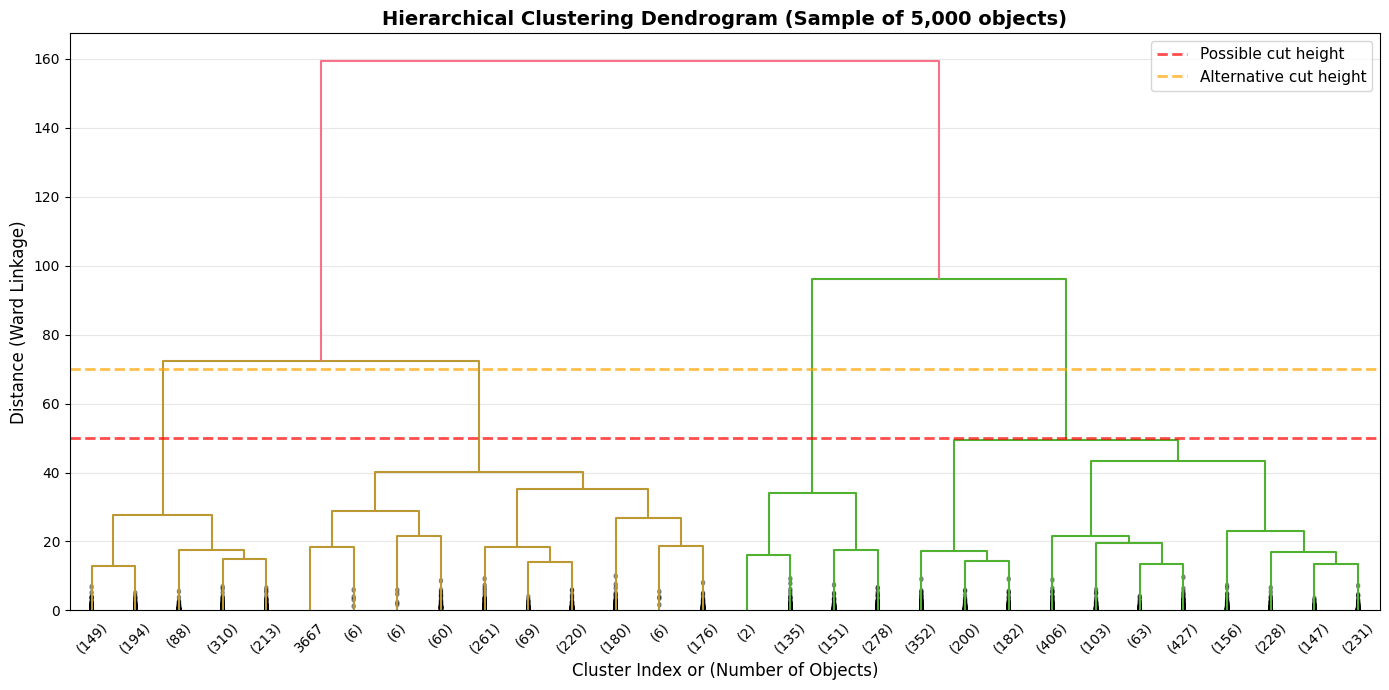


💡 Look for large vertical distances between merges to identify optimal number of clusters
   The horizontal lines suggest potential cut heights


In [3]:
# Perform hierarchical clustering on dendrogram sample using fastcluster
print("Performing hierarchical clustering (Ward linkage) with fastcluster...")
print("This is much faster than scipy's implementation!")
linkage_matrix = fastcluster.linkage(X_dendrogram, method='ward')
print(f"✓ Linkage matrix computed: {linkage_matrix.shape}")

# Create dendrogram to visualize cluster hierarchy
fig, ax = plt.subplots(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    ax=ax,
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=30,  # Show last 30 merges
    leaf_font_size=10,
    show_contracted=True,
)

ax.set_xlabel('Cluster Index or (Number of Objects)', fontsize=12)
ax.set_ylabel('Distance (Ward Linkage)', fontsize=12)
ax.set_title(f'Hierarchical Clustering Dendrogram (Sample of {dendrogram_sample_size:,} objects)', 
             fontsize=14, fontweight='bold')
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Possible cut height')
ax.axhline(y=70, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Alternative cut height')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Look for large vertical distances between merges to identify optimal number of clusters")
print("   The horizontal lines suggest potential cut heights")


## Cluster Assignment

Based on the dendrogram, we'll test different numbers of clusters (4-6 are typical for HR diagram populations).


In [ ]:
# Test different numbers of clusters
n_clusters_options = [4, 5, 6]

# Perform clustering on larger sample using fastcluster
print(f"Performing hierarchical clustering on {clustering_sample_size:,} objects (fastcluster)...")
linkage_clustering = fastcluster.linkage(X_clustering, method='ward')
print(f"✓ Linkage matrix computed: {linkage_clustering.shape}")

# Store cluster assignments for different n_clusters
cluster_results_sample = {}

for n_clusters in n_clusters_options:
    # Get cluster labels using fcluster
    clusters = fcluster(linkage_clustering, n_clusters, criterion='maxclust')
    cluster_results_sample[n_clusters] = clusters
    
    # Count objects per cluster
    unique, counts = np.unique(clusters, return_counts=True)
    
    print(f"\n{n_clusters} Clusters (on {clustering_sample_size:,} sample):")
    for cluster_id, count in zip(unique, counts):
        pct = 100 * count / len(clusters)
        print(f"  Cluster {cluster_id}: {count:6,} objects ({pct:5.1f}%)")

# Assign clusters to the sample used for clustering
data_sample = data.iloc[clustering_indices].copy()
data_sample['cluster_4'] = cluster_results_sample[4]
data_sample['cluster_5'] = cluster_results_sample[5]
data_sample['cluster_6'] = cluster_results_sample[6]

print(f"\n✓ Added cluster assignments to sample dataframe ({len(data_sample):,} objects)")
print(f"⚠️  Note: Using {clustering_sample_size:,} sample for visualization (full dataset too large for memory)")


## Visualize Clusters on HR Diagrams

We'll create HR diagrams using different color-magnitude combinations to see how the clusters separate stellar populations.


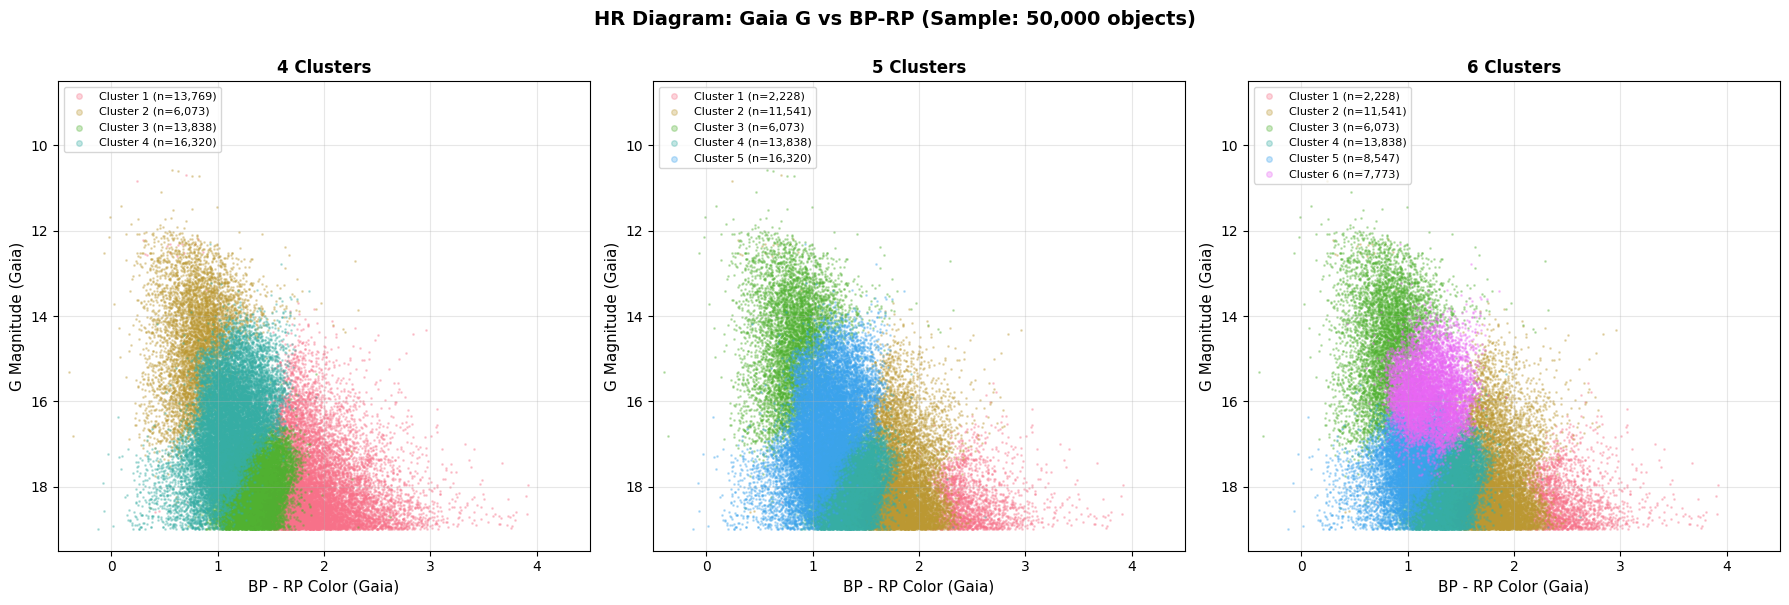

In [5]:
# HR Diagram: Gaia G magnitude vs BP-RP color
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, n_clusters in enumerate(n_clusters_options):
    ax = axes[idx]
    
    # Get cluster labels from sample
    clusters = data_sample[f'cluster_{n_clusters}']
    
    # Plot each cluster with different color
    for cluster_id in sorted(clusters.unique()):
        mask = clusters == cluster_id
        count = mask.sum()
        
        ax.scatter(
            data_sample.loc[mask, 'bp_rp'],
            data_sample.loc[mask, 'phot_g_mean_mag'],
            s=1,
            alpha=0.3,
            label=f'Cluster {cluster_id} (n={count:,})',
            rasterized=True
        )
    
    ax.invert_yaxis()  # HR diagram convention: bright stars on top
    ax.set_xlabel('BP - RP Color (Gaia)', fontsize=11)
    ax.set_ylabel('G Magnitude (Gaia)', fontsize=11)
    ax.set_title(f'{n_clusters} Clusters', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=4, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(19.5, 8.5)

fig.suptitle(f'HR Diagram: Gaia G vs BP-RP (Sample: {len(data_sample):,} objects)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


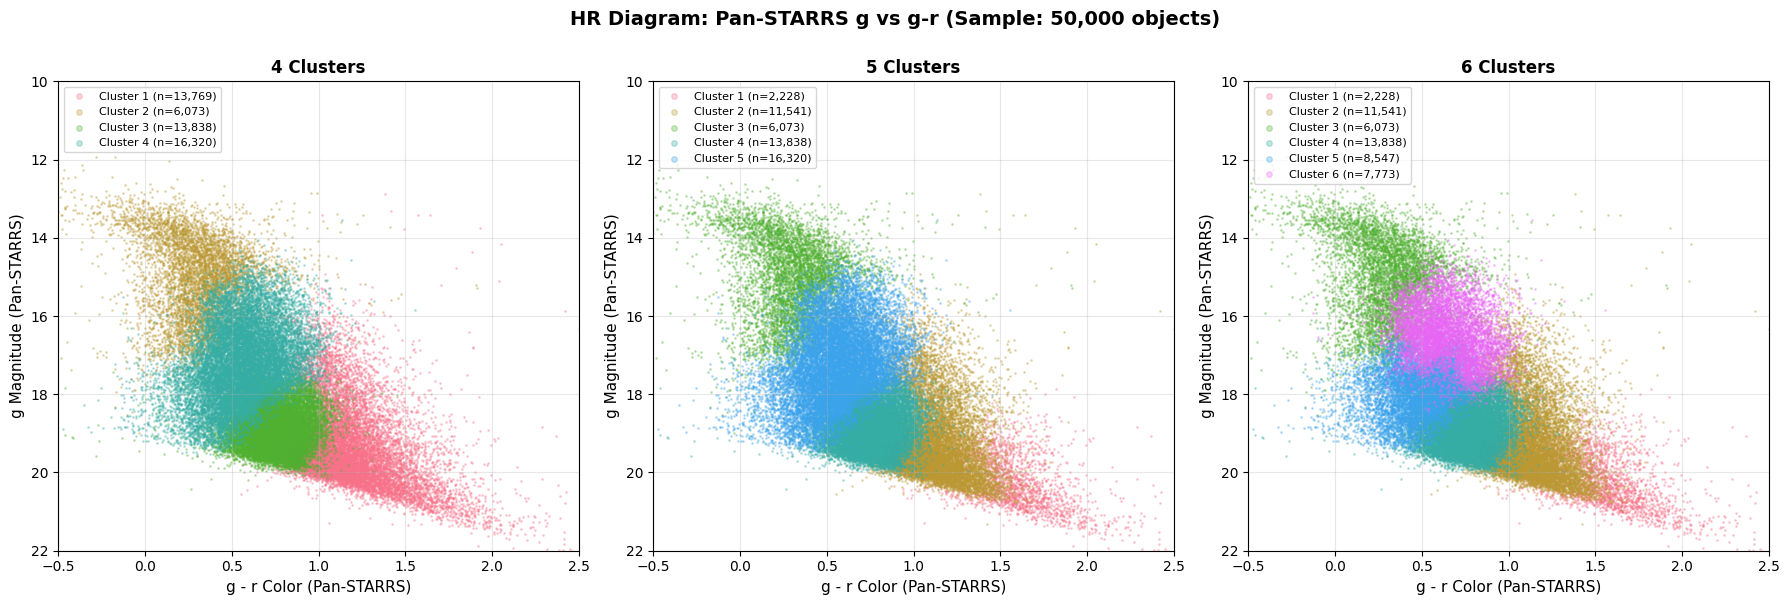

In [6]:
# HR Diagram: Pan-STARRS g magnitude vs g-r color
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, n_clusters in enumerate(n_clusters_options):
    ax = axes[idx]
    
    # Get cluster labels from sample
    clusters = data_sample[f'cluster_{n_clusters}']
    
    # Plot each cluster with different color
    for cluster_id in sorted(clusters.unique()):
        mask = clusters == cluster_id
        count = mask.sum()
        
        ax.scatter(
            data_sample.loc[mask, 'g_r_color'],
            data_sample.loc[mask, 'gPSFMag'],
            s=1,
            alpha=0.3,
            label=f'Cluster {cluster_id} (n={count:,})',
            rasterized=True
        )
    
    ax.invert_yaxis()  # HR diagram convention: bright stars on top
    ax.set_xlabel('g - r Color (Pan-STARRS)', fontsize=11)
    ax.set_ylabel('g Magnitude (Pan-STARRS)', fontsize=11)
    ax.set_title(f'{n_clusters} Clusters', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, markerscale=4, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(22, 10)

fig.suptitle(f'HR Diagram: Pan-STARRS g vs g-r (Sample: {len(data_sample):,} objects)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Cluster Characterization

Let's analyze the physical properties of each cluster (temperature, colors, magnitude).


In [7]:
# Analyze cluster properties (using 5-cluster solution as example)
n_clusters = 5
cluster_col = f'cluster_{n_clusters}'

print(f"{'='*80}")
print(f"CLUSTER CHARACTERIZATION ({n_clusters} Clusters - Sample: {len(data_sample):,} objects)")
print(f"{'='*80}\n")

# Properties to analyze
properties = {
    'Temperature (K)': 'teff_gspphot',
    'BP-RP (Gaia)': 'bp_rp',
    'g-r (PS)': 'g_r_color',
    'B-V': 'B_V_color',
    'G mag (Gaia)': 'phot_g_mean_mag',
    'g mag (PS)': 'gPSFMag'
}

for cluster_id in sorted(data_sample[cluster_col].unique()):
    mask = data_sample[cluster_col] == cluster_id
    n_objects = mask.sum()
    
    print(f"Cluster {cluster_id}: {n_objects:,} objects ({100*n_objects/len(data_sample):.1f}%)")
    print("-" * 80)
    
    for prop_name, col_name in properties.items():
        values = data_sample.loc[mask, col_name]
        median = values.median()
        q25 = values.quantile(0.25)
        q75 = values.quantile(0.75)
        
        print(f"  {prop_name:20s}: median={median:8.2f}  "
              f"[Q25={q25:7.2f}, Q75={q75:7.2f}]")
    
    print()

print(f"{'='*80}")


CLUSTER CHARACTERIZATION (5 Clusters - Sample: 50,000 objects)

Cluster 1: 2,228 objects (4.5%)
--------------------------------------------------------------------------------
  Temperature (K)     : median= 3896.52  [Q25=3659.61, Q75=4523.94]
  BP-RP (Gaia)        : median=    2.42  [Q25=   2.30, Q75=   2.62]
  g-r (PS)            : median=    1.55  [Q25=   1.42, Q75=   1.71]
  B-V                 : median=    1.61  [Q25=   1.50, Q75=   1.76]
  G mag (Gaia)        : median=   18.43  [Q25=  17.96, Q75=  18.77]
  g mag (PS)          : median=   20.33  [Q25=  19.77, Q75=  20.72]

Cluster 2: 11,541 objects (23.1%)
--------------------------------------------------------------------------------
  Temperature (K)     : median= 4199.85  [Q25=3856.49, Q75=4869.88]
  BP-RP (Gaia)        : median=    1.79  [Q25=   1.67, Q75=   1.96]
  g-r (PS)            : median=    1.11  [Q25=   1.00, Q75=   1.23]
  B-V                 : median=    1.22  [Q25=   1.13, Q75=   1.33]
  G mag (Gaia)        : med

## Temperature Distribution by Cluster

Visualize how temperature varies across clusters.


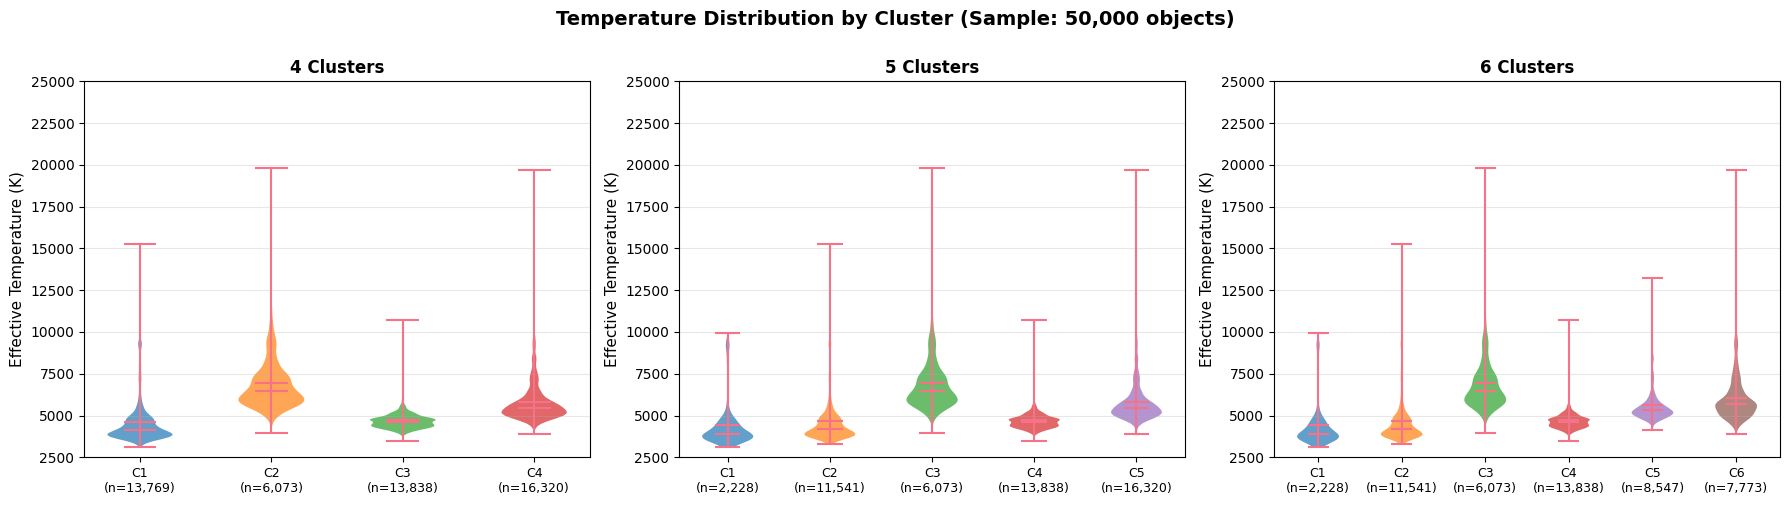

In [8]:
# Temperature distributions for each cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n_clusters in enumerate(n_clusters_options):
    ax = axes[idx]
    cluster_col = f'cluster_{n_clusters}'
    
    # Prepare data for violin plot
    cluster_data = []
    cluster_labels = []
    
    for cluster_id in sorted(data_sample[cluster_col].unique()):
        mask = data_sample[cluster_col] == cluster_id
        temps = data_sample.loc[mask, 'teff_gspphot'].values
        cluster_data.append(temps)
        cluster_labels.append(f'C{cluster_id}\n(n={len(temps):,})')
    
    # Create violin plot
    parts = ax.violinplot(cluster_data, positions=range(1, n_clusters+1), 
                          showmeans=True, showmedians=True)
    
    # Color the violins
    colors = plt.cm.tab10(np.arange(n_clusters))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    ax.set_xticks(range(1, n_clusters+1))
    ax.set_xticklabels(cluster_labels, fontsize=9)
    ax.set_ylabel('Effective Temperature (K)', fontsize=11)
    ax.set_title(f'{n_clusters} Clusters', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(2500, 25000)

fig.suptitle(f'Temperature Distribution by Cluster (Sample: {len(data_sample):,} objects)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
